In [ ]:
# step 1 load and explore the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx

In [2]:
triples = []

with open("../data/train.txt", "r") as f:
    for line in f:
        head, relation, tail = line.strip().split()
        triples.append((head, relation, tail))

print(f"Total triples loaded: {len(triples)}")


Total triples loaded: 13821


In [3]:
df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
df.head()
# print(df['relation'].value_counts())


,head,relation,tail
0,olivia0,sisterOf,selina10
1,olivia0,sisterOf,isabella11
2,olivia0,sisterOf,oskar24
3,olivia0,sisterOf,adam9
4,olivia0,secondAuntOf,lena18


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13821 entries, 0 to 13820
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   head      13821 non-null  str  
 1   relation  13821 non-null  str  
 2   tail      13821 non-null  str  
dtypes: str(3)
memory usage: 324.1 KB


In [5]:
nodes = pd.unique(df[["head", "tail"]].values.ravel())
node_list = list(nodes)

print(f"Total unique nodes: {len(node_list)}")
node_list[:10]
relation_list = df['relation'].unique().tolist()
print(f"Total unique relations: {len(relation_list)}")
relation_list[:10]

Total unique nodes: 1316
Total unique relations: 28


['sisterOf',
 'secondAuntOf',
 'girlCousinOf',
 'daughterOf',
 'granddaughterOf',
 'nieceOf',
 'motherOf',
 'greatAuntOf',
 'grandmotherOf',
 'auntOf']

In [6]:
node_to_id = {node: idx for idx, node in enumerate(node_list)}
relation_to_id = {rel: idx for idx, rel in enumerate(relation_list)}


In [7]:
list(node_to_id.items())[:5]


[('olivia0', 0),
 ('selina10', 1),
 ('isabella11', 2),
 ('oskar24', 3),
 ('adam9', 4)]

In [8]:
G = nx.DiGraph()

for head, relation, tail in triples:
    G.add_edge(head, tail, relation=relation)

print("Graph created successfully!")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Graph created successfully!
Nodes: 1316
Edges: 13821


In [9]:
# Print a few edges with relations
edges_sample = list(G.edges(data=True))[:5]
edges_sample


[('olivia0', 'selina10', {'relation': 'sisterOf'}),
 ('olivia0', 'isabella11', {'relation': 'sisterOf'}),
 ('olivia0', 'oskar24', {'relation': 'sisterOf'}),
 ('olivia0', 'adam9', {'relation': 'sisterOf'}),
 ('olivia0', 'lena18', {'relation': 'secondAuntOf'})]

In [10]:
print("=== Dataset Summary ===")
print("Triples:", len(triples))
print("Entities:", len(node_list))
print("Relations:", len(relation_list))
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())


=== Dataset Summary ===
Triples: 13821
Entities: 1316
Relations: 28
Graph nodes: 1316
Graph edges: 13821


In [11]:
# step 2 # do some basic analysis on the dataset and visualize the distribution of relations and find insights
relation_counts = df["relation"].value_counts() 

relation_dist_df = relation_counts.reset_index()
relation_dist_df.columns = ["relation", "count"]
relation_dist_df

# storing in dataframe for better visualization and easy analysis later on (may be i think it is useful for later steps)

,relation,count
0,grandsonOf,814
1,grandmotherOf,813
2,grandfatherOf,813
3,granddaughterOf,812
4,motherOf,733
5,fatherOf,733
6,sisterOf,636
7,daughterOf,628
8,greatGrandsonOf,624
9,greatGrandmotherOf,617


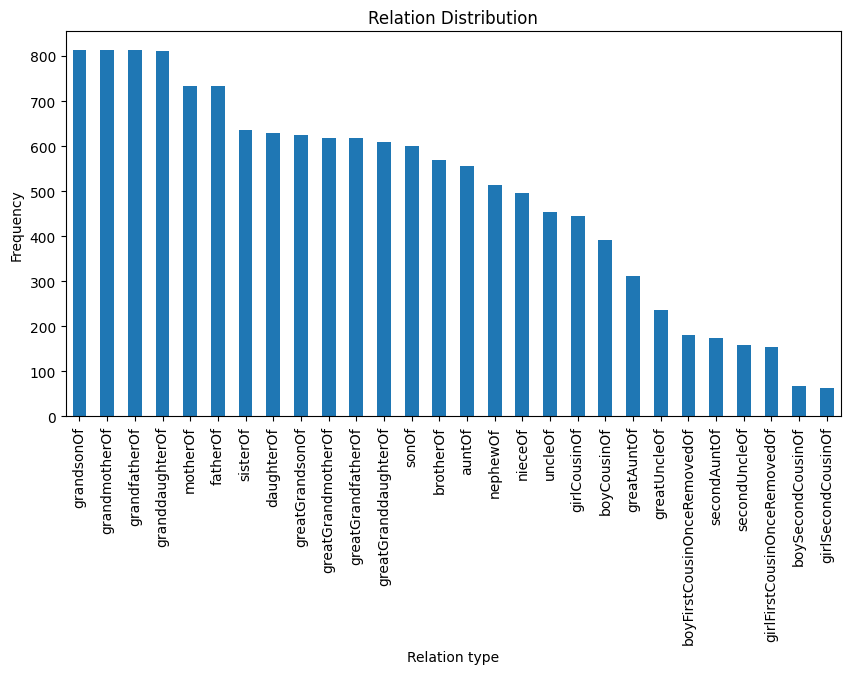

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
relation_counts.plot(kind="bar")
plt.xlabel("Relation type")
plt.ylabel("Frequency")
plt.title("Relation Distribution")
plt.show()


In [13]:
#I think The distribution shows that parental relations dominate the dataset, indicating a skewed but realistic family structure.becuase in realistic family datasets, parental relationships are often more common than sibling or spousal relationships, reflecting typical family dynamics.


In [14]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
degree_df = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[n] for n in G.nodes()],
    "out_degree": [out_degrees[n] for n in G.nodes()]
})

degree_df.head()



,node,in_degree,out_degree
0,olivia0,19,20
1,selina10,21,21
2,isabella11,21,21
3,oskar24,21,21
4,adam9,21,21


In [15]:
degree_stats = {
    "in_degree_mean": degree_df["in_degree"].mean(),
    "in_degree_median": degree_df["in_degree"].median(),
    "in_degree_max": degree_df["in_degree"].max(),
    "out_degree_mean": degree_df["out_degree"].mean(),
    "out_degree_median": degree_df["out_degree"].median(),
    "out_degree_max": degree_df["out_degree"].max(),
}

degree_stats


{'in_degree_mean': np.float64(10.50227963525836),
 'in_degree_median': np.float64(11.0),
 'in_degree_max': np.int64(23),
 'out_degree_mean': np.float64(10.50227963525836),
 'out_degree_median': np.float64(11.0),
 'out_degree_max': np.int64(22)}

In [16]:
k = int(input("Enter the value of k to find top-k nodes by degree: "))

top_out = degree_df.sort_values("out_degree", ascending=False).head(k)
top_in = degree_df.sort_values("in_degree", ascending=False).head(k)

top_out, top_in


(          node  in_degree  out_degree
 139  fabian140         22          22,
              node  in_degree  out_degree
 1032  dominik1036         23          22)

In [17]:
# high out degree nodes are likely to be parents or ancestors in the family tree, as they have many outgoing edges to their children.(but again we cant say for sure without knowing the actual entities) 
# High in-degree nodes are likely to be individuals who are central in the family network.

In [18]:
G_undirected = nx.Graph(G.to_undirected())
components = list(nx.connected_components(G_undirected))

num_components = len(components)
component_sizes = [len(c) for c in components]

print("Number of connected components:", num_components)
print("Largest component size:", max(component_sizes))


Number of connected components: 50
Largest component size: 27


In [19]:
component_size_df = pd.Series(component_sizes).value_counts().sort_index()
component_size_df


26    34
27    16
Name: count, dtype: int64

In [20]:
density = nx.density(G_undirected)
density


0.008644700498110416

In [21]:
largest_component_nodes = max(components, key=len)
G_lcc = G_undirected.subgraph(largest_component_nodes)


In [22]:
avg_path_length = nx.average_shortest_path_length(G_lcc)
diameter = nx.diameter(G_lcc)

avg_path_length, diameter

# small diameter -> tight family structure
# large diameter -> more extended family structure

(1.4700854700854702, 3)

In [23]:
avg_clustering = nx.average_clustering(G_undirected)
avg_clustering

0.790834609985262

In [24]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_relations = len(relation_list)

summary = {
    "nodes": num_nodes,
    "edges": num_edges,
    "relations": num_relations,
    "components": num_components,
    "largest_component_size": max(component_sizes),
    "density": density,
    "avg_shortest_path": avg_path_length,
    "diameter": diameter,
    "avg_clustering": avg_clustering
}

summary

{'nodes': 1316,
 'edges': 13821,
 'relations': 28,
 'components': 50,
 'largest_component_size': 27,
 'density': 0.008644700498110416,
 'avg_shortest_path': 1.4700854700854702,
 'diameter': 3,
 'avg_clustering': 0.790834609985262}

In [25]:
# step-3 : Family‑specific structural insights
degree_centrality = nx.degree_centrality(G_undirected)

degree_cent_df = (
    pd.Series(degree_centrality)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

degree_cent_df.columns = ["node", "degree_centrality"]
degree_cent_df


,node,degree_centrality
0,magdalena1044,0.01749
1,oliver1045,0.01749
2,lisa1035,0.01749
3,olivia1043,0.01749
4,dominik1036,0.01749
5,magdalena59,0.01673
6,claudia69,0.01673
7,tobias57,0.01673
8,larissa408,0.01673
9,jonas419,0.01673


In [26]:
betweenness = nx.betweenness_centrality(G_undirected)

betweenness_df = (
    pd.Series(betweenness)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

betweenness_df.columns = ["node", "betweenness"]
betweenness_df


,node,betweenness
0,lea1165,0.000128
1,valentin638,0.000121
2,gabriel241,0.000109
3,nora536,0.000106
4,stefan1192,0.000105
5,simon172,0.000101
6,helena1135,0.000097
7,gabriel1140,0.000097
8,raphael29,0.000096
9,katharina889,0.000089


In [27]:
closeness = nx.closeness_centrality(G_undirected)

closeness_df = (
    pd.Series(closeness)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

closeness_df.columns = ["node", "closeness"]
closeness_df


,node,closeness
0,lisa1035,0.017726
1,oliver1045,0.017726
2,magdalena1044,0.017726
3,olivia1043,0.017726
4,dominik1036,0.017726
5,nora825,0.017136
6,fabian140,0.017136
7,gabriel146,0.017136
8,elias6,0.017136
9,lisa5,0.017136


In [28]:
eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000)

eigenvector_df = (
    pd.Series(eigenvector)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

eigenvector_df.columns = ["node", "eigenvector"]
eigenvector_df

,node,eigenvector
0,oliver1045,0.238609
1,magdalena1044,0.238609
2,lisa1035,0.238609
3,dominik1036,0.238609
4,olivia1043,0.238609
5,philipp1031,0.229525
6,lena1038,0.229525
7,marlene1033,0.229525
8,julia1032,0.229525
9,theodor1029,0.226551


In [29]:
G_parent = nx.DiGraph()

for _, row in df.iterrows():
    h, r, t = row["head"], row["relation"], row["tail"]
    
    if r in ["motherOf", "fatherOf"]:
        G_parent.add_edge(h, t)
    elif r in ["sonOf", "daughterOf"]:
        G_parent.add_edge(t, h)


In [30]:
roots = [n for n in G_parent.nodes() if G_parent.in_degree(n) == 0]


In [31]:
generation = {}

for root in roots:
    for node, depth in nx.single_source_shortest_path_length(G_parent, root).items():
        if node not in generation or depth < generation[node]:
            generation[node] = depth


In [32]:
generation_df = pd.Series(generation).reset_index()
generation_df.columns = ["node", "generation"]

generation_df.head()


,node,generation
0,emma7,0
1,katharina1,1
2,paula12,1
3,natalie13,1
4,luis14,1


In [33]:
generation_distribution = generation_df["generation"].value_counts().sort_index()

generation_distribution


generation
0    495
1    614
2    207
Name: count, dtype: int64

In [34]:
threshold = pd.Series(betweenness).quantile(0.95)

bridge_nodes = [n for n, b in betweenness.items() if b >= threshold]

len(bridge_nodes), bridge_nodes[:10]


(67,
 ['lena18',
  'raphael29',
  'claudia69',
  'tobias57',
  'magdalena59',
  'oliver165',
  'simon172',
  'marko180',
  'adam198',
  'oliver207'])

In [35]:
component_clustering = []

for component in nx.connected_components(G_undirected):
    subgraph = G_undirected.subgraph(component)
    if len(subgraph) > 2:
        component_clustering.append(nx.average_clustering(subgraph))

In [36]:
pd.Series(component_clustering).describe()

count    50.000000
mean      0.790880
std       0.048336
min       0.688478
25%       0.758074
50%       0.794153
75%       0.817512
max       0.896310
dtype: float64

In [37]:
duplicate_mask = df.duplicated(keep=False)
duplicate_triples = df[duplicate_mask]

num_duplicates = duplicate_triples.shape[0]

num_duplicates
duplicate_triples


,head,relation,tail
